In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, multilabel_confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.multiclass import OneVsRestClassifier

warnings.filterwarnings("ignore", category=FutureWarning)


In [13]:

# Load dataset
df = pd.read_csv(r"C:\Users\Moitree\Downloads\cuisine classification\Dataset.csv")


In [ ]:
# Drop rows with missing cuisines
df.dropna(subset=['Cuisines'], inplace=True)

# Extract cuisines into list
df['Cuisine_Main'] = df['Cuisines'].apply(
    lambda x: [c.strip() for c in x.split(',') if len(c.strip()) > 2]
)

# Multi-label encode cuisines
mlb = MultiLabelBinarizer()
cuisine_encoded = mlb.fit_transform(df['Cuisine_Main'])

# Select features
features = df[['Average Cost for two', 'Price range', 'Aggregate rating',
               'Has Table booking', 'Has Online delivery']].copy()

# Convert Yes/No to 1/0
features['Has Table booking'] = features['Has Table booking'].map({'Yes': 1, 'No': 0})
features['Has Online delivery'] = features['Has Online delivery'].map({'Yes': 1, 'No': 0})

# Create boolean mask for rows with no missing values
valid_mask = features.notnull().all(axis=1)

# Apply the mask to both features and cuisine_encoded
features = features[valid_mask]
cuisine_encoded = cuisine_encoded[valid_mask.to_numpy()]

# Remove cuisine labels that occur too few times
min_label_count = 5
label_counts = cuisine_encoded.sum(axis=0)
valid_labels_mask = label_counts >= min_label_count
cuisine_encoded = cuisine_encoded[:, valid_labels_mask]
mlb.classes_ = mlb.classes_[valid_labels_mask]


In [15]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    features, cuisine_encoded, test_size=0.2, random_state=42
)


In [16]:
# Preprocessing pipeline
numeric_features = ['Average Cost for two', 'Aggregate rating']
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features)
], remainder='passthrough')

# Model pipeline
model = Pipeline([
    ('preprocess', preprocessor),
    ('clf', OneVsRestClassifier(RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight='balanced')))
])



In [17]:

# Train the model
model.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['Average Cost for two',
                                                   'Aggregate rating'])])),
                ('clf',
                 OneVsRestClassifier(estimator=RandomForestClassifier(class_weight='balanced',
                                                                      random_state=42)))])

In [18]:

y_pred = model.predict(X_test)

# Classification report
report = classification_report(
    y_test,
    y_pred,
    target_names=mlb.classes_,
    zero_division=0,
    output_dict=True
)

print("Classification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=mlb.classes_,
    zero_division=0
))

# Confusion matrix
print("\nConfusion Matrix:\n")
print(multilabel_confusion_matrix(y_test, y_pred))


Classification Report:

                   precision    recall  f1-score   support

          Afghani       0.02      0.25      0.03         4
          African       0.00      0.00      0.00         3
         American       0.20      0.51      0.28        73
           Andhra       0.00      0.00      0.00         2
          Arabian       0.00      0.00      0.00         2
            Asian       0.08      0.20      0.12        50
       Australian       0.00      0.00      0.00         1
           Awadhi       0.00      0.00      0.00         0
              BBQ       0.09      0.50      0.15         8
           Bakery       0.12      0.52      0.20       135
         Bar Food       0.07      0.15      0.10        13
          Bengali       0.00      0.00      0.00         7
        Beverages       0.03      0.29      0.06        35
           Bihari       0.00      0.00      0.00         0
          Biryani       0.03      0.37      0.06        35
        Brazilian       0.20   

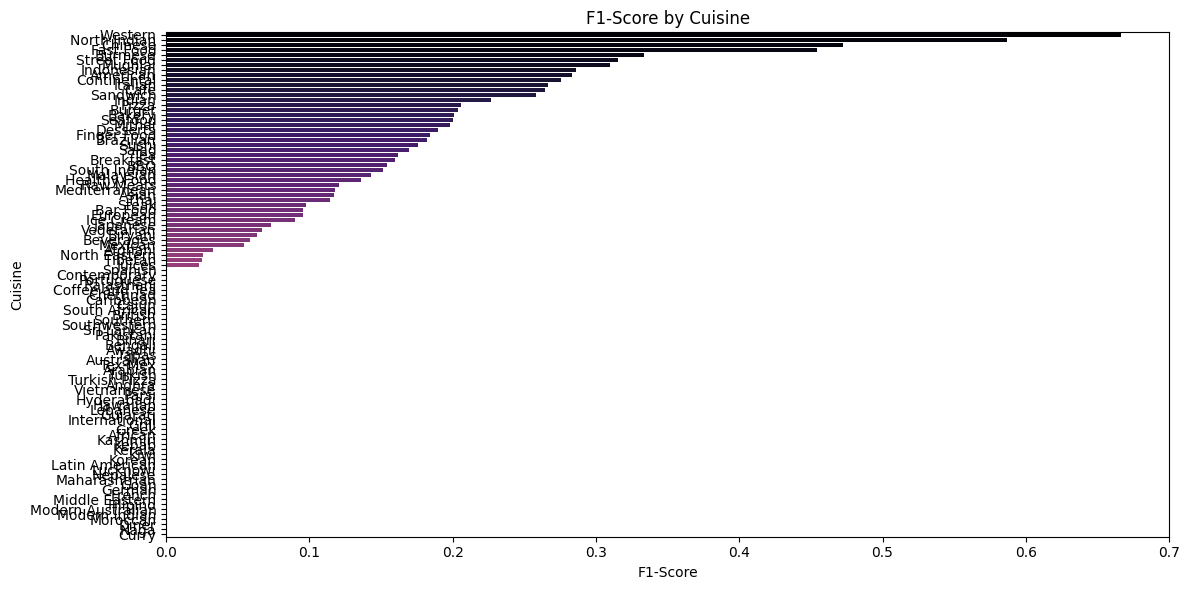

In [19]:
# Plot F1-score
f1_scores = {label: values['f1-score'] for label, values in report.items() if label in mlb.classes_}
f1_df = pd.DataFrame(list(f1_scores.items()), columns=['Cuisine', 'F1-Score'])
f1_df = f1_df.sort_values(by='F1-Score', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='F1-Score', y='Cuisine', data=f1_df, palette='magma')
plt.title('F1-Score by Cuisine')
plt.xlabel('F1-Score')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()

In [20]:
#save the model
import joblib
joblib.dump(model,"cuisine_pipeline_model.pkl")
joblib.dump(mlb,"cuisine_multilevel_encoder.pkl")
print("model ,mlb are saved successfully")


model ,mlb are saved successfully


In [21]:
#prediction  function
def predict_cuisine(user_input: dict, top_n=3, threshold=0.3):
    input_df = pd.DataFrame([user_input])

    # Convert Yes/No to binary
    input_df['Has Table booking'] = input_df['Has Table booking'].map({'Yes': 1, 'No': 0})
    input_df['Has Online delivery'] = input_df['Has Online delivery'].map({'Yes': 1, 'No': 0})

    # Ensure correct column order
    input_df = input_df[features.columns]

    # Predict probabilities
    proba = model.predict_proba(input_df)

    # Apply threshold
    binary_pred = (proba >= threshold).astype(int)

    if not binary_pred.any():
        # If no probabilities exceed threshold, pick top_n highest
        top_indices = np.argsort(proba[0])[::-1][:top_n]
        predicted_labels = [mlb.classes_[i] for i in top_indices]
    else:
        predicted_labels = [mlb.classes_[i] for i in np.where(binary_pred[0] == 1)[0]]

    return predicted_labels 

In [ ]:
#Test the model with input
sample_input = {
   'Average Cost for two': 25000, 
   'Price range': 4,
   'Aggregate rating': 3.5,
   'Has Table booking': 'No',
   'Has Online delivery': 'Yes'
}
print("Predicted Cuisines:", predict_cuisine(sample_input)) 

Predicted Cuisines: ['Chinese', 'North Indian']


In [12]:
sample_input = {
    'Average Cost for two': 400,
    'Price range': 1,
    'Aggregate rating': 3.3,
    'Has Table booking': 'no',
    'Has Online delivery': 'yes'
}

print("\nPredicted Cuisines for User Input:", predict_cuisine(sample_input))



Predicted Cuisines for User Input: ['Bakery', 'Beverages', 'Burger', 'Chinese', 'Desserts', 'Fast Food', 'Hyderabadi', 'Ice Cream', 'Mithai', 'Mughlai', 'North Indian', 'Raw Meats', 'South Indian', 'Street Food']


In [61]:
sample_input = {
'Average Cost for two': 1000, 
'Price range': 3,
'Aggregate rating': 3.6,
'Has Table booking': 'yes',
'Has Online delivery': 'no'
}


print("Predicted Cuisines:", predict_cuisine(sample_input))

Predicted Cuisines: ['Asian', 'Bakery', 'Biryani', 'Cafe', 'Chinese', 'Continental', 'Fast Food', 'Finger Food', 'Hyderabadi', 'North Indian']


In [13]:
sample_input = {
   'Average Cost for two': 500, 
   'Price range': 4,
   'Aggregate rating': 3.6,
   'Has Table booking': 'yes',
   'Has Online delivery': 'no'
}
print("Predicted Cuisines:", predict_cuisine(sample_input)) 

Predicted Cuisines: ['Sushi']


In [14]:
sample_input = {
    'Average Cost for two': 500,
    'Price range': 2,
    'Aggregate rating': 2,
    'Has Table booking': 'No',
    'Has Online delivery': 'No'
}

print("Predicted Cuisines:", predict_cuisine(sample_input))

Predicted Cuisines: ['Chinese', 'Mughlai', 'North Indian']


In [15]:
sample_input = {
   'Average Cost for two': 50, 
   'Price range': 1,
   'Aggregate rating': 4,
   'Has Table booking': 'No',
   'Has Online delivery': 'No'
}
print("Predicted Cuisines:", predict_cuisine(sample_input)) 

Predicted Cuisines: ['Street Food']
